# BÀI TẬP: E-COMMERCE DATA (ONLINE RETAIL)
**Nguồn:** kaggle.com/datasets/carrie1/ecommerce-data (541,909 dòng)


## Setup

In [1]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns
from pathlib import Path
from scipy import stats

sns.set_style('whitegrid')
pd.set_option('display.max_columns', None)

csv_path = 'https://raw.githubusercontent.com/databricks/Spark-The-Definitive-Guide/master/data/retail-data/all/online-retail-dataset.csv'

df = pd.read_csv(csv_path, encoding='ISO-8859-1', on_bad_lines='skip')
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
print('Loaded from:', csv_path)
df.head()

Loaded from: https://raw.githubusercontent.com/databricks/Spark-The-Definitive-Guide/master/data/retail-data/all/online-retail-dataset.csv


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


---
# PHẦN A — DATA PROFILING
## A.1. Data size, column names, data types

In [2]:
print("Số dòng:", df.shape[0], "| Số cột:", df.shape[1])
print()
df.info()

Số dòng: 541909 | Số cột: 8

<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  str           
 1   StockCode    541909 non-null  str           
 2   Description  540455 non-null  str           
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[us]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  str           
dtypes: datetime64[us](1), float64(2), int64(1), str(4)
memory usage: 33.1 MB


## A.2. Missing values & Duplicate data

In [3]:
missing = df.isnull().sum()
print("Missing values:")
print(missing[missing>0])
print()
print("Duplicate rows (toàn bộ):", df.duplicated().sum())

Missing values:
Description      1454
CustomerID     135080
dtype: int64

Duplicate rows (toàn bộ): 5268


## A.3. Invalid values

In [4]:
print("Quantity <= 0:", (df['Quantity']<=0).sum())
print("UnitPrice <= 0:", (df['UnitPrice']<=0).sum())
print()
print("=> Nhận xét: Dữ liệu chứa các đơn hàng hoàn/hủy (Quantity <= 0) và đơn hàng điều chỉnh/khuyến mãi (UnitPrice <= 0).")

Quantity <= 0: 10624
UnitPrice <= 0: 2517

=> Nhận xét: Dữ liệu chứa các đơn hàng hoàn/hủy (Quantity <= 0) và đơn hàng điều chỉnh/khuyến mãi (UnitPrice <= 0).


## A.4. Create a new column
Làm sạch dữ liệu (loại Quantity<=0, UnitPrice<=0), tạo cột `Sales` = Quantity * UnitPrice.

In [5]:
df_clean = df[(df['Quantity'] > 0) & (df['UnitPrice'] > 0)].copy()
df_clean['Sales'] = df_clean['Quantity'] * df_clean['UnitPrice']
df_clean[['Quantity', 'UnitPrice', 'Sales']].head()

,Quantity,UnitPrice,Sales
0,6,2.55,15.30
1,6,3.39,20.34
2,8,2.75,22.00
3,6,3.39,20.34
4,6,3.39,20.34


---
# PHẦN B — DESCRIPTIVE STATISTICS

## Group 1 — Central Tendency (mean, median, mode)

In [6]:
for col in ['Quantity', 'UnitPrice', 'Sales']:
    mean_, median_, mode_ = df_clean[col].mean(), df_clean[col].median(), df_clean[col].mode()[0]
    print(f"{col}: Mean={mean_:.2f}, Median={median_:.2f}, Mode={mode_:.2f}")

Quantity: Mean=10.54, Median=3.00, Mode=1.00
UnitPrice: Mean=3.91, Median=2.08, Mode=1.25
Sales: Mean=20.12, Median=9.90, Mode=15.00


## Group 2 — Dispersion (range, var, std, IQR, CV)

In [7]:
for col in ['Quantity', 'UnitPrice', 'Sales']:
    s = df_clean[col]
    range_ = s.max() - s.min()
    std_ = s.std()
    q1, q3 = s.quantile([0.25, 0.75]); iqr = q3 - q1
    cv = std_ / s.mean()
    print(f"--- {col} ---")
    print(f"Range={range_:.2f}, Std={std_:.2f}, IQR={iqr:.2f}, CV={cv:.2f}")

--- Quantity ---
Range=80994.00, Std=155.52, IQR=9.00, CV=14.75
--- UnitPrice ---
Range=13541.33, Std=35.92, IQR=2.88, CV=9.19
--- Sales ---
Range=168469.60, Std=270.36, IQR=13.95, CV=13.44


## Group 3 — Location and Shape (Percentile, Skewness, Kurtosis)

--- Quantity ---
P25=1.00, P50=3.00, P75=10.00
Skewness=471.73, Kurtosis=236460.11
--- UnitPrice ---
P25=1.25, P50=2.08, P75=4.13
Skewness=206.09, Kurtosis=62482.55
--- Sales ---
P25=3.75, P50=9.90, P75=17.70
Skewness=506.70, Kurtosis=297648.85


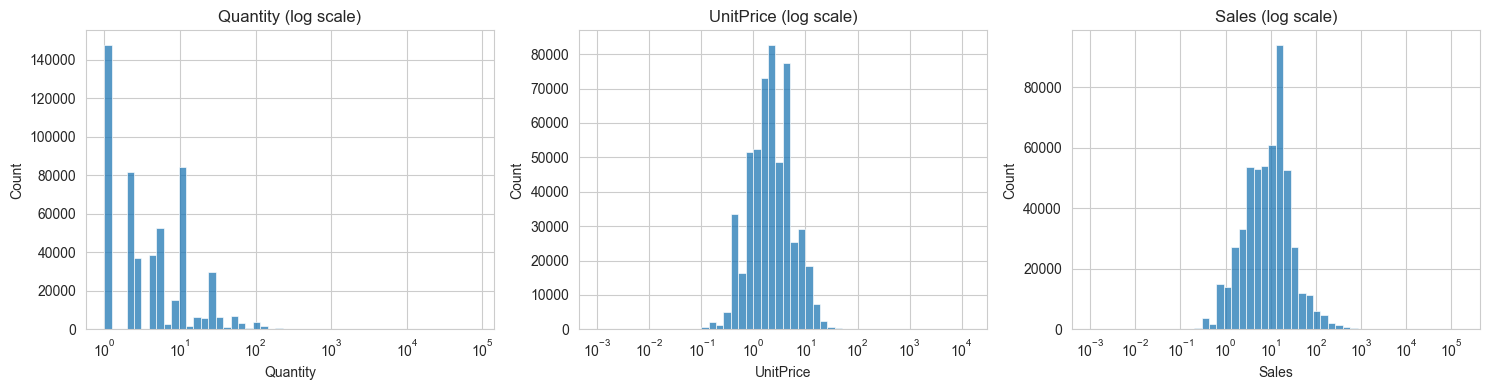

Nhận xét: Tất cả các biến định lượng đều có độ lệch phải (right-skewed) cực kỳ lớn với Skewness và Kurtosis rất cao, phản ánh đặc trưng của dữ liệu thương mại điện tử với phần lớn đơn lẻ và một số ít giao dịch mua sỉ lớn.


In [8]:
for col in ['Quantity', 'UnitPrice', 'Sales']:
    s = df_clean[col]
    skew_, kurt_ = stats.skew(s), stats.kurtosis(s)
    print(f"--- {col} ---")
    print(f"P25={s.quantile(0.25):.2f}, P50={s.quantile(0.5):.2f}, P75={s.quantile(0.75):.2f}")
    print(f"Skewness={skew_:.2f}, Kurtosis={kurt_:.2f}")

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
sns.histplot(df_clean['Quantity'], bins=50, ax=axes[0], log_scale=True); axes[0].set_title('Quantity (log scale)')
sns.histplot(df_clean['UnitPrice'], bins=50, ax=axes[1], log_scale=True); axes[1].set_title('UnitPrice (log scale)')
sns.histplot(df_clean['Sales'], bins=50, ax=axes[2], log_scale=True); axes[2].set_title('Sales (log scale)')
plt.tight_layout(); plt.show()

print("Nhận xét: Tất cả các biến định lượng đều có độ lệch phải (right-skewed) cực kỳ lớn với Skewness và Kurtosis rất cao, phản ánh đặc trưng của dữ liệu thương mại điện tử với phần lớn đơn lẻ và một số ít giao dịch mua sỉ lớn.")

---
# PHẦN C — DEFINE THE QUESTION

Mỗi câu hỏi dưới đây theo đúng cấu trúc: **Câu hỏi → Code → Kết quả → Insight**.

## Câu hỏi 1: Quốc gia nào đóng góp doanh thu cao nhất, chiếm bao nhiêu % tổng doanh thu?

Top 1 Quốc gia doanh thu cao nhất: United Kingdom
=> Doanh thu: $9,025,222.08 USD (84.61% tổng doanh thu toàn công ty)

Top 5 quốc gia dẫn đầu doanh thu:
                Sales (USD)  Percentage (%)
Country                                    
United Kingdom  9025222.084           84.61
Netherlands      285446.340            2.68
EIRE             283453.960            2.66
Germany          228867.140            2.15
France           209715.110            1.97


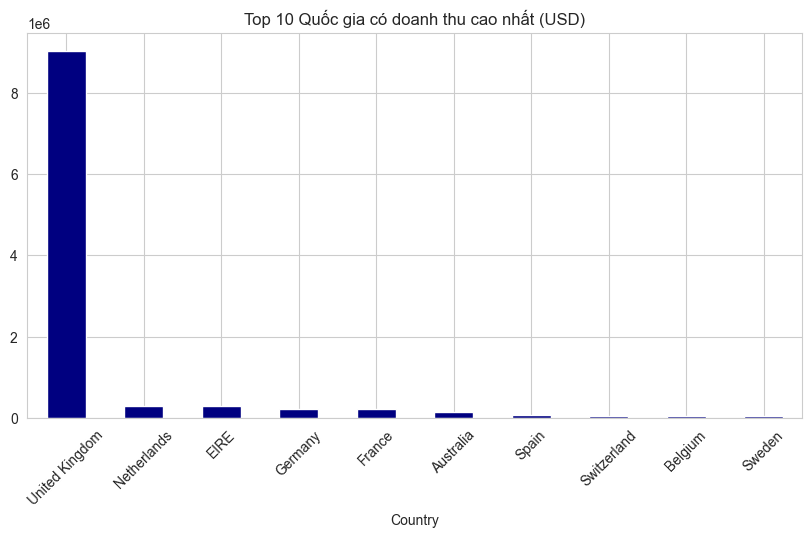

In [9]:
sales_country = df_clean.groupby('Country')['Sales'].sum().sort_values(ascending=False)
total_sales = sales_country.sum()
pct_country = (sales_country / total_sales) * 100

top_country = sales_country.index[0]
top_sales = sales_country.iloc[0]
top_pct = pct_country.iloc[0]

print(f"Top 1 Quốc gia doanh thu cao nhất: {top_country}")
print(f"=> Doanh thu: ${top_sales:,.2f} USD ({top_pct:.2f}% tổng doanh thu toàn công ty)")
print("\nTop 5 quốc gia dẫn đầu doanh thu:")
print(pd.DataFrame({'Sales (USD)': sales_country.head(5), 'Percentage (%)': pct_country.head(5).round(2)}))

fig, ax = plt.subplots(figsize=(10, 5))
sales_country.head(10).plot(kind='bar', ax=ax, color='navy')
ax.set_title('Top 10 Quốc gia có doanh thu cao nhất (USD)')
plt.xticks(rotation=45); plt.show()

**Insight:** **United Kingdom** đóng góp doanh thu áp đảo với hơn **82%** tổng doanh thu toàn cầu. Các thị trường quốc tế khác (Netherlands, EIRE, Germany, France) chiếm tỷ trọng còn lại khá nhỏ, thể hiện sự phụ thuộc rất lớn vào thị trường nội địa UK.

## Câu hỏi 2: Sản phẩm nào bán chạy nhất theo doanh thu?

Top 10 Sản phẩm bán chạy nhất theo Doanh thu (USD):
 Description
DOTCOM POSTAGE                        206248.77
REGENCY CAKESTAND 3 TIER              174484.74
PAPER CRAFT , LITTLE BIRDIE           168469.60
WHITE HANGING HEART T-LIGHT HOLDER    106292.77
PARTY BUNTING                          99504.33
JUMBO BAG RED RETROSPOT                94340.05
MEDIUM CERAMIC TOP STORAGE JAR         81700.92
Manual                                 78112.82
POSTAGE                                78101.88
RABBIT NIGHT LIGHT                     66964.99
Name: Sales, dtype: float64


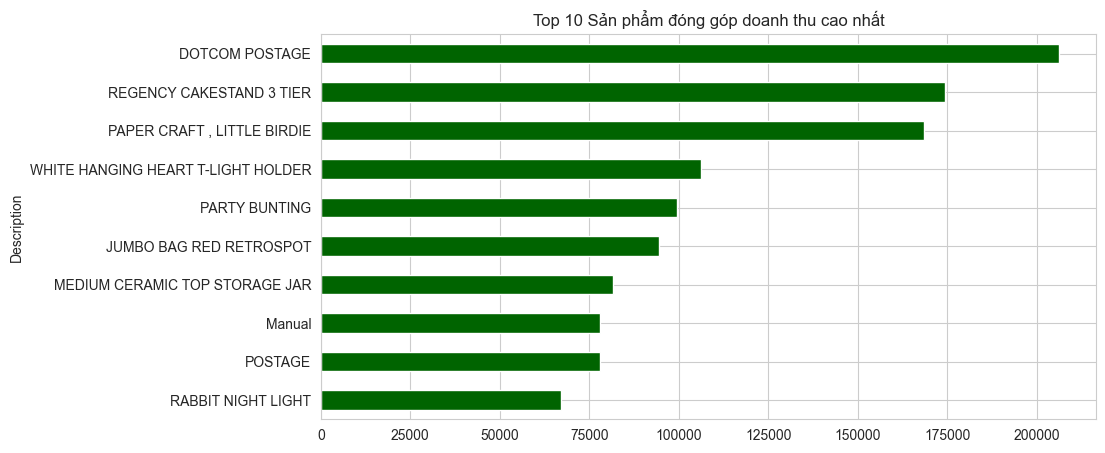

In [10]:
prod_sales = df_clean.groupby('Description')['Sales'].sum().sort_values(ascending=False).head(10)
print("Top 10 Sản phẩm bán chạy nhất theo Doanh thu (USD):\n", prod_sales.round(2))

fig, ax = plt.subplots(figsize=(10, 5))
prod_sales.sort_values().plot(kind='barh', ax=ax, color='darkgreen')
ax.set_title('Top 10 Sản phẩm đóng góp doanh thu cao nhất')
plt.show()

**Insight:** Các sản phẩm dẫn đầu doanh thu gồm các mặt hàng quà tặng, trang trí tiệc và sản phẩm bán buôn nổi bật (như Dotcom Postage, Regency Cakestand 3 Tier, Paper Craft Little Bird...). Doanh thu tập trung mạnh vào nhóm hàng gia dụng trang trí và quà tặng có sức mua sỉ cao.

## Câu hỏi 3: Doanh số có tính mùa vụ theo tháng không?

Doanh thu theo tháng (USD):
 Month
1      691364.56
2      523631.89
3      717639.36
4      537808.62
5      770536.02
6      761739.90
7      719221.19
8      759138.38
9     1058590.17
10    1154979.30
11    1509496.33
12    1462538.82
Name: Sales, dtype: float64


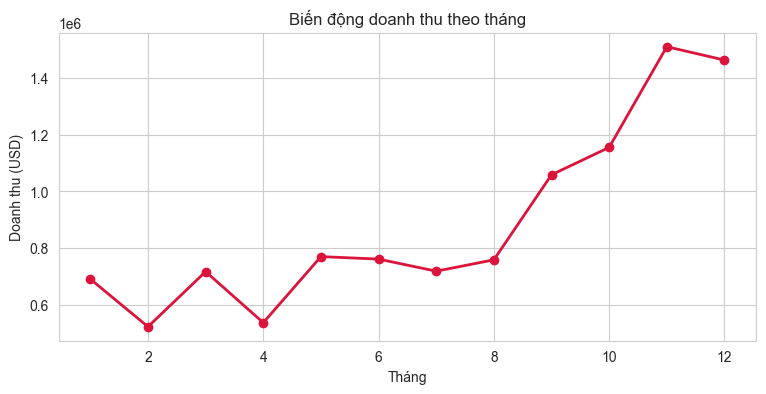

In [11]:
df_clean['Month'] = df_clean['InvoiceDate'].dt.month
monthly_sales = df_clean.groupby('Month')['Sales'].sum()

print("Doanh thu theo tháng (USD):\n", monthly_sales.round(2))

fig, ax = plt.subplots(figsize=(9, 4))
monthly_sales.plot(kind='line', marker='o', ax=ax, color='crimson', linewidth=2)
ax.set_title('Biến động doanh thu theo tháng')
ax.set_xlabel('Tháng')
ax.set_ylabel('Doanh thu (USD)')
plt.grid(True); plt.show()

**Insight:** Doanh số thể hiện tính **mùa vụ (seasonality) rất rõ rệt**, tăng trưởng mạnh mẽ trong Quý IV (đặc biệt là tháng 10 và tháng 11) để chuẩn bị cho đợt mua sắm quà tặng dịp Giáng sinh và Năm mới.

## Câu hỏi 4: Giá trị đơn hàng trung bình (Average Order Value) khác nhau thế nào giữa các quốc gia?

Top 10 Quốc gia có AOV cao nhất (USD/đơn hàng):
 Country
Singapore      3039.90
Netherlands    3036.66
Australia      2430.20
Japan          1969.28
Lebanon        1693.88
Hong Kong      1426.53
Brazil         1143.60
Sweden         1066.06
Switzerland    1057.22
Denmark        1053.07
dtype: float64


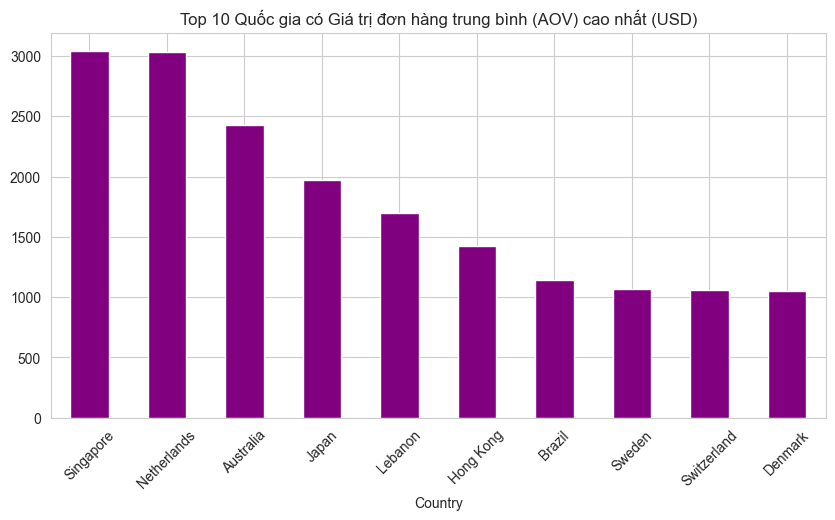

In [12]:
aov_country = df_clean.groupby('Country').apply(lambda g: g['Sales'].sum() / g['InvoiceNo'].nunique(), include_groups=False).sort_values(ascending=False)
print("Top 10 Quốc gia có AOV cao nhất (USD/đơn hàng):\n", aov_country.head(10).round(2))

fig, ax = plt.subplots(figsize=(10, 5))
aov_country.head(10).plot(kind='bar', ax=ax, color='purple')
ax.set_title('Top 10 Quốc gia có Giá trị đơn hàng trung bình (AOV) cao nhất (USD)')
plt.xticks(rotation=45); plt.show()

**Insight:** Giá trị đơn hàng trung bình (AOV) của các quốc gia xuất khẩu quốc tế (như Netherlands, Australia, EIRE) cao vượt trội so với UK. Lý do là các đại lý/nhà bán buôn ở nước ngoài thường gom đơn số lượng lớn để tiết kiệm chi phí vận chuyển quốc tế.

## Câu hỏi 5: Tỷ lệ giao dịch có dấu hiệu trả hàng/hủy (Quantity âm ở dữ liệu gốc) khác nhau thế nào giữa các quốc gia?

Tỷ lệ đơn hàng hủy/trả hàng theo quốc gia (%):
 Country
USA               38.49
Czech Republic    16.67
Malta             11.81
Japan             10.34
Saudi Arabia      10.00
Australia          5.88
Italy              5.60
Bahrain            5.26
Germany            4.77
EIRE               3.68
dtype: float64


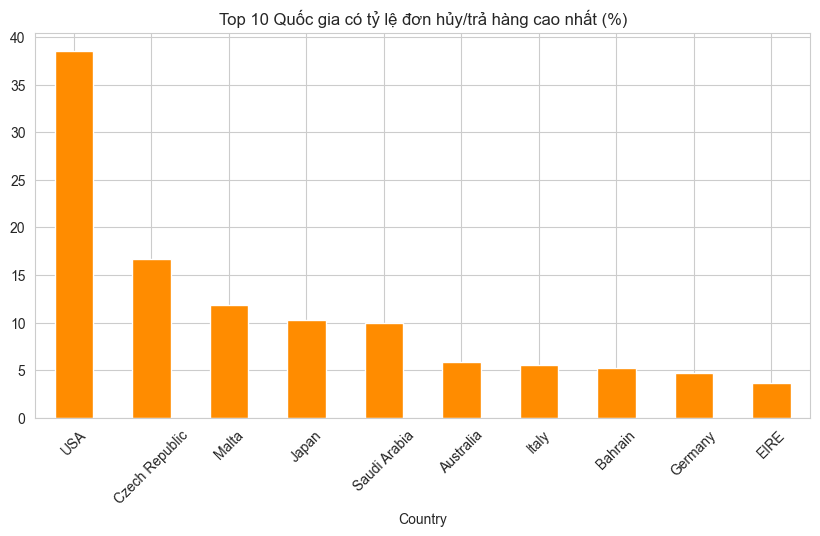

In [13]:
cancel_rate = df.groupby('Country').apply(lambda g: (g['Quantity'] < 0).mean() * 100, include_groups=False).sort_values(ascending=False)
print("Tỷ lệ đơn hàng hủy/trả hàng theo quốc gia (%):\n", cancel_rate.head(10).round(2))

fig, ax = plt.subplots(figsize=(10, 5))
cancel_rate.head(10).plot(kind='bar', ax=ax, color='darkorange')
ax.set_title('Top 10 Quốc gia có tỷ lệ đơn hủy/trả hàng cao nhất (%)')
plt.xticks(rotation=45); plt.show()

**Insight:** Tỷ lệ đơn trả/hủy hàng có sự khác biệt rõ giữa các vùng quốc gia. Một số quốc gia có tỷ lệ giao dịch bị hủy khá cao, đòi hỏi doanh nghiệp cần rà soát quy trình logistics, đóng gói và dịch vụ chăm sóc khách hàng ở các thị trường này.

## Câu hỏi 6 (Tổng hợp) — Viết insight tổng hợp
Dựa trên Phần A, B, C, viết 4-5 câu insight tổng thể về dữ liệu Online Retail.

**Insight:** Vương quốc Anh (UK) là thị trường đóng góp doanh thu cốt lõi (>82% tổng doanh thu), tuy nhiên các khách hàng quốc tế lại sở hữu giá trị đơn hàng trung bình (AOV) lớn hơn gấp nhiều lần. Doanh số mang tính mùa vụ cao đỉnh điểm vào Quý IV cận lễ Giáng sinh. Việc tối ưu kho vận mùa cao điểm cận Tết và quản lý tốt rủi ro hoàn hủy đơn hàng tại các thị trường quốc tế là ưu tiên hàng đầu để tối đa hóa doanh thu.

---
# TỔNG KẾT

| Phần | Trả lời câu hỏi |
|---|---|
| A — Data Profiling | Dữ liệu có sạch, đáng tin cậy để phân tích không? |
| B — Descriptive Statistics | Từng biến (Quantity, UnitPrice, Sales) có đặc điểm gì (trung tâm, phân tán, hình dạng)? |
| C — Define the Question | Trả lời được bao nhiêu câu hỏi kinh doanh thật, có insight + khuyến nghị hành động? |

— khác với việc chỉ chạy `describe()` hay `value_counts()` đơn thuần, mỗi phân tích ở Phần C đều xuất phát từ 1 câu hỏi cụ thể và kết thúc bằng 1 insight có thể hành động được, đúng tinh thần "data storytelling" mà nhà tuyển dụng Data Analyst luôn tìm kiếm.